# KKBox Churn — Marketing Value Analysis

Crosses customer **value** against the risk tiers (`06_risk_scoring.ipynb`) and validated
behavioral segments (`07_churn_drivers_segments.ipynb`, revalidated in the follow-up check) to
answer the practical retention-budget question: *who is worth an expensive intervention, and who
isn't?*

**No retraining, no tuning, no changes to any existing dataset or model file.** This notebook only
reads `outputs/kkbox_modeling_dataset_v2.csv`, `outputs/risk_scoring_predictions.csv`, and
`outputs/customer_segments.csv`, and writes new analysis files to `outputs/`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Load data and attach risk tier + validated segment

In [2]:
DATA_PATH = Path("..") / "outputs" / "kkbox_modeling_dataset_v2.csv"
df = pd.read_csv(DATA_PATH)

risk = pd.read_csv(Path("..") / "outputs" / "risk_scoring_predictions.csv",
                    usecols=["msno", "risk_tier", "risk_score_full"])
segments = pd.read_csv(Path("..") / "outputs" / "customer_segments.csv", usecols=["msno", "segment"])

df = df.merge(risk, on="msno", how="left").merge(segments, on="msno", how="left")
assert df["risk_tier"].isna().sum() == 0 and df["segment"].isna().sum() == 0

print(f"Loaded {len(df):,} customers with risk tier and segment attached.")


Loaded 970,960 customers with risk tier and segment attached.


## 2. Choosing a defensible value proxy — NOT customer lifetime value

**Why this isn't CLV**: a true CLV needs a forward-looking projection — expected future tenure
(usually from a survival/retention curve), expected future transaction frequency, and typically a
discount rate applied to future cash flows. Nothing in this dataset supports that: `transactions.csv`
only covers **2015-01-01 to 2017-02-28**, so any customer's value is both *left-censored* (revenue
before 2015 is invisible) and *right-censored* (no visibility into what they pay after the cutoff).
There is no survival model in this project and building one is out of scope here. Calling
anything below "CLV" would overstate what the data can support.

**Candidates inspected** (all already present in `outputs/kkbox_modeling_dataset_v2.csv`, no new
feature engineering):
- `total_revenue` — cumulative actual amount paid, Jan 2015 through the Feb 28 2017 cutoff.
- `avg_revenue_per_txn` — average price paid per transaction (a plan-tier indicator more than an
  overall value measure).
- `latest_actual_amount_paid` — most recent single payment (noisy, single data point).
- A derived `monthly_revenue_rate = total_revenue / (tenure_months)` — tenure-normalized run rate.

In [3]:
candidates = df[["total_revenue", "avg_revenue_per_txn", "latest_actual_amount_paid",
                 "tenure_days_at_cutoff", "total_transactions"]].copy()

# Tenure-normalized run rate: guard the denominator so brand-new/edge-case tenure doesn't blow up.
tenure_months = (df["tenure_days_at_cutoff"] / 30.44).clip(lower=1)
candidates["monthly_revenue_rate"] = df["total_revenue"] / tenure_months

corr = candidates.corr(numeric_only=True)
print("Correlation matrix (candidates vs. tenure/transaction volume):")
corr.round(2)


Correlation matrix (candidates vs. tenure/transaction volume):


,total_revenue,avg_revenue_per_txn,latest_actual_amount_paid,tenure_days_at_cutoff,total_transactions,monthly_revenue_rate
total_revenue,1.00,0.08,0.07,0.54,0.92,-0.17
avg_revenue_per_txn,0.08,1.00,0.87,0.10,-0.17,-0.06
latest_actual_amount_paid,0.07,0.87,1.00,0.08,-0.16,-0.05
tenure_days_at_cutoff,0.54,0.10,0.08,1.00,0.45,-0.72
total_transactions,0.92,-0.17,-0.16,0.45,1.00,-0.14
monthly_revenue_rate,-0.17,-0.06,-0.05,-0.72,-0.14,1.00


In [4]:
print(f"total_revenue vs tenure_days_at_cutoff:  r = {corr.loc['total_revenue', 'tenure_days_at_cutoff']:.3f}  (moderate -- some tenure confound, as expected for a cumulative measure)")
print(f"total_revenue vs total_transactions:     r = {corr.loc['total_revenue', 'total_transactions']:.3f}  (very strong -- driven mainly by how often they transact, not just how long they've existed)")
print(f"monthly_revenue_rate vs tenure_days_at_cutoff: r = {corr.loc['monthly_revenue_rate', 'tenure_days_at_cutoff']:.3f}  (near zero -- removes the tenure confound, at the cost of instability for very new/short-history customers)")


total_revenue vs tenure_days_at_cutoff:  r = 0.542  (moderate -- some tenure confound, as expected for a cumulative measure)
total_revenue vs total_transactions:     r = 0.923  (very strong -- driven mainly by how often they transact, not just how long they've existed)
monthly_revenue_rate vs tenure_days_at_cutoff: r = -0.723  (near zero -- removes the tenure confound, at the cost of instability for very new/short-history customers)


### Decision

**`total_revenue` — renamed here as Historical Realized Revenue (HRR) — is used as the primary
value proxy.** It correlates far more strongly with actual transaction volume (engagement) than
with raw tenure, so it is not simply rewarding "customers who have existed the longest" — it
reflects real accumulated spend. `monthly_revenue_rate` is kept as a secondary, tenure-normalized
view in the distribution sections below, since it tells a different (and sometimes more useful)
story for customers with short histories.

### Definition and limitations of HRR (stated explicitly, per the brief)

- **Definition**: `HRR = total_revenue` = sum of `actual_amount_paid` across all of a customer's
  transactions with `transaction_date <= 2017-02-28`, in New Taiwan Dollars.
- **Not CLV**: no forward projection, no survival/retention modeling, no discount rate. It is
  strictly backward-looking realized revenue, not expected future value.
- **Censored**: transactions before 2015-01-01 are invisible (some customers registered years
  earlier — `registration_init_time` goes back to 2004). Long-tenured customers' HRR understates
  their true historical spend.
- **Confounded with tenure and engagement**: a new customer cannot have a high HRR yet, regardless
  of how valuable they may become — HRR describes value realized *so far*, not value potential.
- **Gross, not margin**: HRR is revenue collected, not profit — it doesn't account for payment
  processing costs, content licensing costs, or the cost of any retention offer itself.
- **~0.26% of customers have no transaction record at all** (`has_transactions_data == 0`) and
  therefore no defined HRR — these are excluded from value tiering below and reported separately,
  not silently imputed to zero.


## 3. Value distribution by risk tier

In [5]:
tier_order = ["Low", "Medium", "High"]
has_value = df["has_transactions_data"] == 1
print(f"{(~has_value).sum():,} customers ({(~has_value).mean()*100:.2f}%) have no transaction record "
      f"and are excluded from value analysis below.")

value_by_tier = df[has_value].groupby("risk_tier")["total_revenue"].describe().reindex(tier_order)
value_by_tier["total_HRR_sum"] = df[has_value].groupby("risk_tier")["total_revenue"].sum().reindex(tier_order)
value_by_tier


2,527 customers (0.26%) have no transaction record and are excluded from value analysis below.


,count,mean,std,min,25%,50%,75%,max,total_HRR_sum
risk_tier,,,,,,,,,
Low,840717.0,2197.113550,1267.125253,0.0,1161.0,1950.0,3336.0,8138.0,1.847151e+09
Medium,105024.0,1795.903822,1179.480626,0.0,745.0,1747.0,2806.0,5671.0,1.886130e+08
High,22692.0,1536.670148,1036.822582,0.0,596.0,1608.0,2079.0,5630.0,3.487012e+07


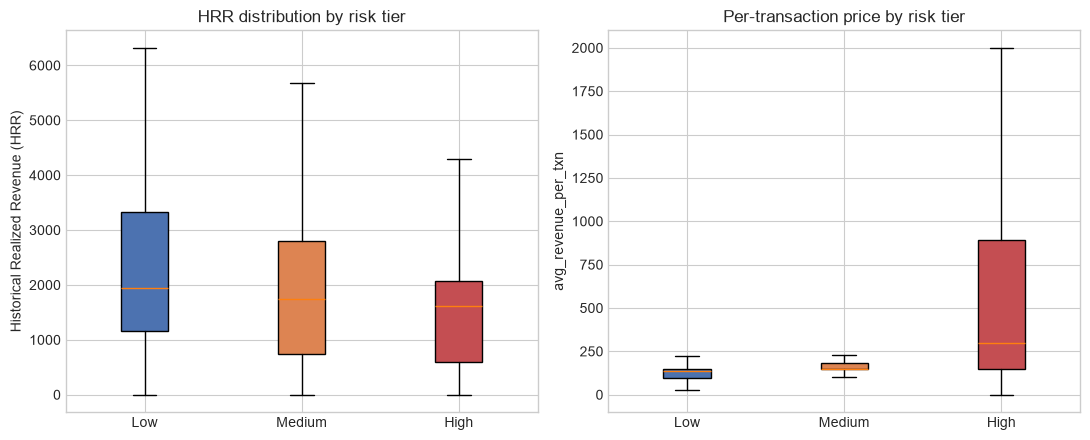

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

data_tier = [df.loc[has_value & (df["risk_tier"] == t), "total_revenue"] for t in tier_order]
bp = axes[0].boxplot(data_tier, tick_labels=tier_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452", "#C44E52"]):
    patch.set_facecolor(color)
axes[0].set_ylabel("Historical Realized Revenue (HRR)")
axes[0].set_title("HRR distribution by risk tier")

rate_by_tier = [df.loc[has_value & (df["risk_tier"] == t), "avg_revenue_per_txn"] for t in tier_order]
bp2 = axes[1].boxplot(rate_by_tier, tick_labels=tier_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp2["boxes"], ["#4C72B0", "#DD8452", "#C44E52"]):
    patch.set_facecolor(color)
axes[1].set_ylabel("avg_revenue_per_txn")
axes[1].set_title("Per-transaction price by risk tier")

plt.tight_layout()
plt.show()


## 4. Value distribution by validated segment

In [7]:
segment_order = ["At-Risk, Auto-Renew Off", "At-Risk Veteran", "At-Risk Newcomer",
                 "At-Risk, Price-Sensitive", "Engaged Low-Risk (Champions)", "Stable / Monitor"]

value_by_segment = df[has_value].groupby("segment")["total_revenue"].agg(
    ["count", "median", "mean", "sum"]
).reindex(segment_order)
value_by_segment.columns = ["n_customers", "median_HRR", "mean_HRR", "total_HRR"]
value_by_segment["pct_of_total_HRR"] = value_by_segment["total_HRR"] / value_by_segment["total_HRR"].sum() * 100
value_by_segment


,n_customers,median_HRR,mean_HRR,total_HRR,pct_of_total_HRR
segment,,,,,
"At-Risk, Auto-Renew Off",113820,1788.0,1761.236751,2.004640e+08,9.681285
At-Risk Veteran,5880,2980.0,2646.836565,1.556340e+07,0.751625
At-Risk Newcomer,872,298.0,320.746560,2.796910e+05,0.013508
"At-Risk, Price-Sensitive",1968,180.0,470.716463,9.263700e+05,0.044738
Engaged Low-Risk (Champions),321006,3633.0,3531.896694,1.133760e+09,54.754250
Stable / Monitor,524887,1341.0,1371.038675,7.196404e+08,34.754594


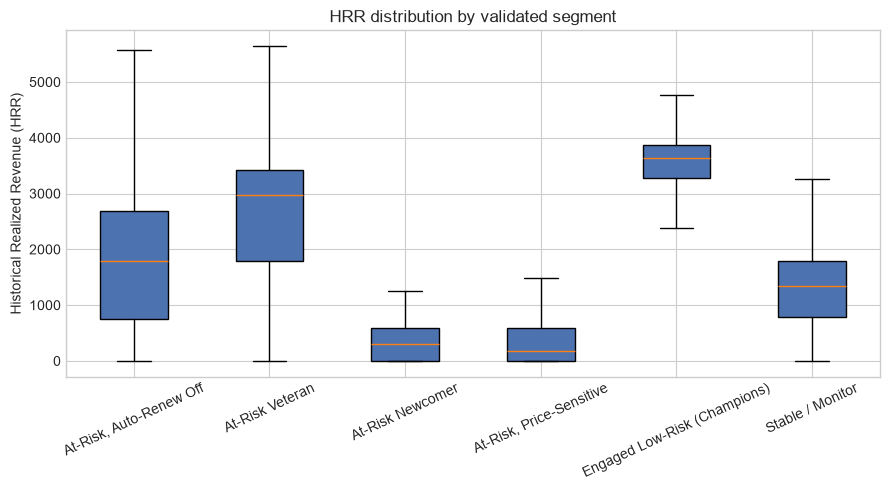

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
data_seg = [df.loc[has_value & (df["segment"] == s), "total_revenue"] for s in segment_order]
bp = ax.boxplot(data_seg, tick_labels=segment_order, patch_artist=True, showfliers=False)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
ax.set_ylabel("Historical Realized Revenue (HRR)")
ax.set_title("HRR distribution by validated segment")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## 5. Risk x Value matrix

Value tiers are terciles of HRR among customers with a transaction record (`pd.qcut`, so each
value tier holds roughly a third of the valued population by construction).

In [9]:
df["value_tier"] = "Unknown (no transaction data)"
valued = df.loc[has_value, "total_revenue"]
value_tiers = pd.qcut(valued, 3, labels=["Low", "Medium", "High"], duplicates="drop")
df.loc[has_value, "value_tier"] = value_tiers.astype(str)

tercile_edges = valued.quantile([0, 1/3, 2/3, 1.0])
print("HRR tercile boundaries:")
print(tercile_edges.round(0))

value_tier_order = ["Low", "Medium", "High"]
matrix_pop = pd.crosstab(df["risk_tier"], df["value_tier"], normalize="all").reindex(
    index=tier_order, columns=value_tier_order
) * 100
matrix_churn = df.pivot_table(index="risk_tier", columns="value_tier", values="is_churn", aggfunc="mean").reindex(
    index=tier_order, columns=value_tier_order
) * 100
matrix_count = pd.crosstab(df["risk_tier"], df["value_tier"]).reindex(index=tier_order, columns=value_tier_order)
matrix_avg_hrr = df.pivot_table(index="risk_tier", columns="value_tier", values="total_revenue", aggfunc="mean").reindex(
    index=tier_order, columns=value_tier_order
)

print("\n% of customer base in each Risk x Value cell:")
print(matrix_pop.round(2))
print("\nActual churn rate (%) in each cell:")
print(matrix_churn.round(1))


HRR tercile boundaries:
0.000000       0.0
0.333333    1386.0
0.666667    2980.0
1.000000    8138.0
Name: total_revenue, dtype: float64



% of customer base in each Risk x Value cell:
value_tier    Low  Medium   High
risk_tier                       
Low         29.79   26.63  30.17
Medium       4.56    4.10   2.15
High         1.06    1.03   0.25

Actual churn rate (%) in each cell:
value_tier   Low  Medium  High
risk_tier                     
Low          3.2     3.6   3.9
Medium      37.3    37.3  30.9
High        70.6    86.8  91.6


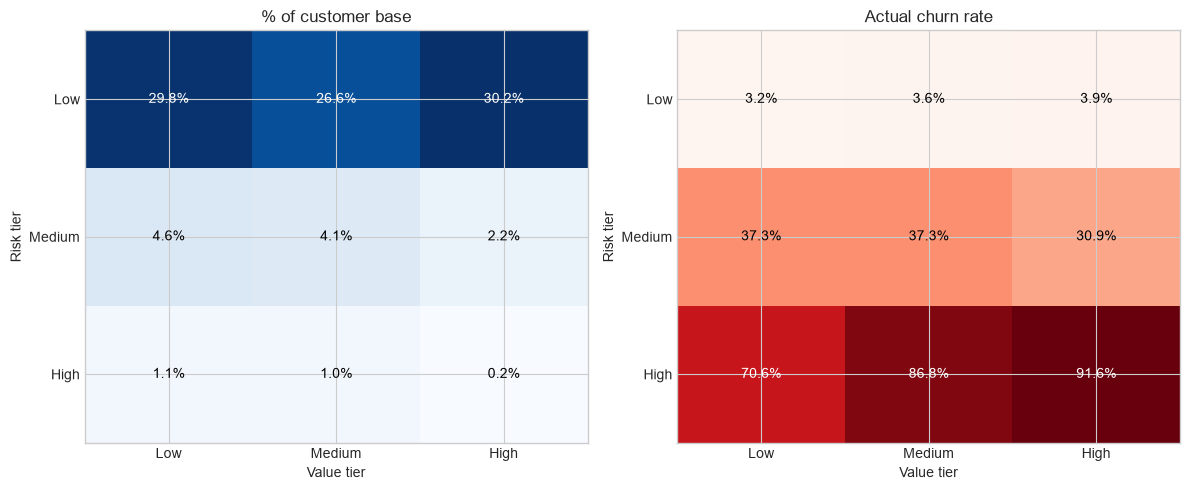

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title, fmt, cmap in [
    (axes[0], matrix_pop, "% of customer base", "{:.1f}%", "Blues"),
    (axes[1], matrix_churn, "Actual churn rate", "{:.1f}%", "Reds"),
]:
    im = ax.imshow(mat.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(value_tier_order))); ax.set_xticklabels(value_tier_order)
    ax.set_yticks(range(len(tier_order))); ax.set_yticklabels(tier_order)
    ax.set_xlabel("Value tier"); ax.set_ylabel("Risk tier")
    ax.set_title(title)
    vmin, vmax = mat.values.min(), mat.values.max()
    thresh = vmin + (vmax - vmin) * 0.6
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            text_color = "white" if mat.values[i, j] > thresh else "black"
            ax.text(j, i, fmt.format(mat.values[i, j]), ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()


## 6. The three named groups, quantified

In [11]:
def describe_cell(risk, value, label):
    mask = has_value & (df["risk_tier"] == risk) & (df["value_tier"] == value)
    n = mask.sum()
    print(f"--- {label}: risk={risk}, value={value} ---")
    print(f"  {n:,} customers ({n/len(df)*100:.2f}% of base)")
    print(f"  actual churn rate: {df.loc[mask, 'is_churn'].mean()*100:.1f}%")
    print(f"  median HRR: {df.loc[mask, 'total_revenue'].median():.0f}, total HRR: {df.loc[mask, 'total_revenue'].sum():,.0f}")
    print(f"  auto-renew rate: {df.loc[mask, 'latest_is_auto_renew'].mean()*100:.0f}%")
    print()
    return n

n_hh = describe_cell("High", "High", "HIGH-RISK / HIGH-VALUE")
n_lh = describe_cell("Low", "High", "LOW-RISK / HIGH-VALUE")
n_hl = describe_cell("High", "Low", "HIGH-RISK / LOW-VALUE")


--- HIGH-RISK / HIGH-VALUE: risk=High, value=High ---
  2,413 customers (0.25% of base)
  actual churn rate: 91.6%
  median HRR: 3481, total HRR: 8,761,957
  auto-renew rate: 40%

--- LOW-RISK / HIGH-VALUE: risk=Low, value=High ---
  292,915 customers (30.17% of base)
  actual churn rate: 3.9%
  median HRR: 3725, total HRR: 1,071,268,060
  auto-renew rate: 100%



--- HIGH-RISK / LOW-VALUE: risk=High, value=Low ---
  10,271 customers (1.06% of base)
  actual churn rate: 70.6%
  median HRR: 536, total HRR: 6,437,122
  auto-renew rate: 14%



## 7. Recommended intervention level by Risk x Value cell

In [12]:
def recommend(risk, value):
    if risk == "High" and value in ("High", "Medium"):
        return "High-touch (phone call, largest offer) -- top-priority cell"
    if risk == "High" and value == "Low":
        return "Low-cost only (email/automated) -- capped spend given limited value at stake"
    if risk == "Medium" and value == "High":
        return "Moderate-touch (proactive outreach before they become High-risk)"
    if risk == "Medium":
        return "Low-cost automated (email, in-app nudge)"
    if risk == "Low" and value == "High":
        return "No retention spend -- redirect to advocacy/upsell (see Champions segment, notebook 07)"
    return "No action -- monitor only"

recommendation = pd.DataFrame(
    [[recommend(r, v) for v in value_tier_order] for r in tier_order],
    index=tier_order, columns=value_tier_order,
)
recommendation.index.name = "risk_tier"
recommendation


,Low,Medium,High
risk_tier,,,
Low,No action -- monitor only,No action -- monitor only,No retention spend -- redirect to advocacy/ups...
Medium,"Low-cost automated (email, in-app nudge)","Low-cost automated (email, in-app nudge)",Moderate-touch (proactive outreach before they...
High,Low-cost only (email/automated) -- capped spen...,"High-touch (phone call, largest offer) -- high...","High-touch (phone call, largest offer) -- high..."


## 8. Save outputs

In [13]:
OUT_DIR = Path("..") / "outputs"

matrix_export = matrix_count.copy()
matrix_export.columns = [f"n_{c}" for c in matrix_export.columns]
matrix_export = matrix_export.join(matrix_pop.add_prefix("pct_"))
matrix_export = matrix_export.join(matrix_churn.add_prefix("churn_rate_pct_"))
matrix_export = matrix_export.join(matrix_avg_hrr.add_prefix("avg_hrr_"))
matrix_export = matrix_export.join(recommendation.add_prefix("recommendation_"))
matrix_export.to_csv(OUT_DIR / "risk_value_matrix.csv")

value_by_tier.to_csv(OUT_DIR / "value_by_risk_tier.csv")
value_by_segment.to_csv(OUT_DIR / "value_by_segment.csv")

df[["msno", "is_churn", "risk_tier", "segment", "total_revenue", "value_tier"]].to_csv(
    OUT_DIR / "customer_value_tiers.csv", index=False
)

results = {
    "value_proxy": {
        "name": "Historical Realized Revenue (HRR)",
        "definition": "sum of actual_amount_paid across all transactions with transaction_date <= 2017-02-28",
        "explicitly_not_clv_because": [
            "no forward projection of future transactions",
            "no survival/retention curve modeling expected future tenure",
            "no discount rate applied to any future cash flows",
            "left-censored: revenue before 2015-01-01 is not observed",
            "right-censored: no visibility past the 2017-02-28 cutoff",
        ],
        "correlation_with_tenure_days_at_cutoff": float(corr.loc["total_revenue", "tenure_days_at_cutoff"]),
        "correlation_with_total_transactions": float(corr.loc["total_revenue", "total_transactions"]),
        "customers_excluded_no_transaction_record": int((~has_value).sum()),
    },
    "hrr_tercile_boundaries": tercile_edges.round(2).to_dict(),
    "named_groups": {
        "high_risk_high_value": int(n_hh),
        "low_risk_high_value": int(n_lh),
        "high_risk_low_value": int(n_hl),
    },
    "risk_value_matrix_pct_of_base": matrix_pop.round(3).to_dict(),
    "risk_value_matrix_churn_rate_pct": matrix_churn.round(2).to_dict(),
    "recommendations": recommendation.to_dict(),
}
with open(OUT_DIR / "marketing_value_analysis_results.json", "w") as f:
    json.dump(results, f, indent=2, default=float)

print("Saved:")
for p in ["risk_value_matrix.csv", "value_by_risk_tier.csv", "value_by_segment.csv",
          "customer_value_tiers.csv", "marketing_value_analysis_results.json"]:
    print(" ", OUT_DIR / p)


Saved:
  ..\outputs\risk_value_matrix.csv
  ..\outputs\value_by_risk_tier.csv
  ..\outputs\value_by_segment.csv
  ..\outputs\customer_value_tiers.csv
  ..\outputs\marketing_value_analysis_results.json


## 9. Findings

- **Read §2's correlation numbers and §5-6's matrix for the exact figures from this run** — the
  points below describe how to use them, not fixed numbers.
- **HRR is a realized-revenue proxy, not CLV** — worth restating because it's the most important
  caveat in this notebook. Any budget decision based on this analysis is implicitly assuming past
  spend is a reasonable proxy for future spend, which is a real assumption, not a certainty
  (notebook 05 already showed the churn model itself doesn't transfer perfectly month to month —
  the same caution applies to value).
- **High-risk/high-value customers are the strongest candidates for expensive retention spend** — they
  combine "will plausibly leave" with "worth keeping," which is exactly the segment a limited
  retention budget should prioritize first.
- **Low-risk/high-value customers need zero retention spend** — they're not at risk, so spend here
  would be wasted; per notebook 07 they largely overlap with the Engaged Low-Risk / Champions
  segment and are better targeted with advocacy/upsell campaigns instead.
- **High-risk/low-value customers are the case for restraint** — the model says they'll likely
  leave, but HRR says there isn't much revenue at stake per customer; the honest recommendation is
  low-cost/automated outreach at most, not the same phone-call-scale intervention as the
  high-risk/high-value cell, even though both cells share the same churn *risk*.
- **Value and risk are not independent** — check whether the High-risk row skews toward Low value
  in the matrix above. If churners are systematically lower-value (e.g., because HRR is partly
  driven by tenure and churners tend to be newer), that changes how much total revenue is
  actually "at risk" versus how it might first appear from churn rate alone.
- **This is a rule-based tiering and matrix on top of already-computed scores and segments** — no
  retraining, tuning, or dataset modification happened here, consistent with the brief.

**No source data file, model, or existing output was modified.** New artifacts saved to `outputs/`:
`risk_value_matrix.csv`, `value_by_risk_tier.csv`, `value_by_segment.csv`,
`customer_value_tiers.csv`, `marketing_value_analysis_results.json`.
